# Importing libraries

In [1]:
import numpy as np
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
import seaborn as sns

import math


C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading the dataset

In [2]:
data_csv = pd.read_csv(r"C:\Users\ismai\Downloads\archive (16)\equipment_anomaly_data.csv")

# Exploratory data analysis

Box plots of the sensors

C:\Users\ismai\AppData\Local\Temp\ipykernel_20364\1725621524.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_20364\1725621524.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_20364\1725621524.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_20364\1725621524.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

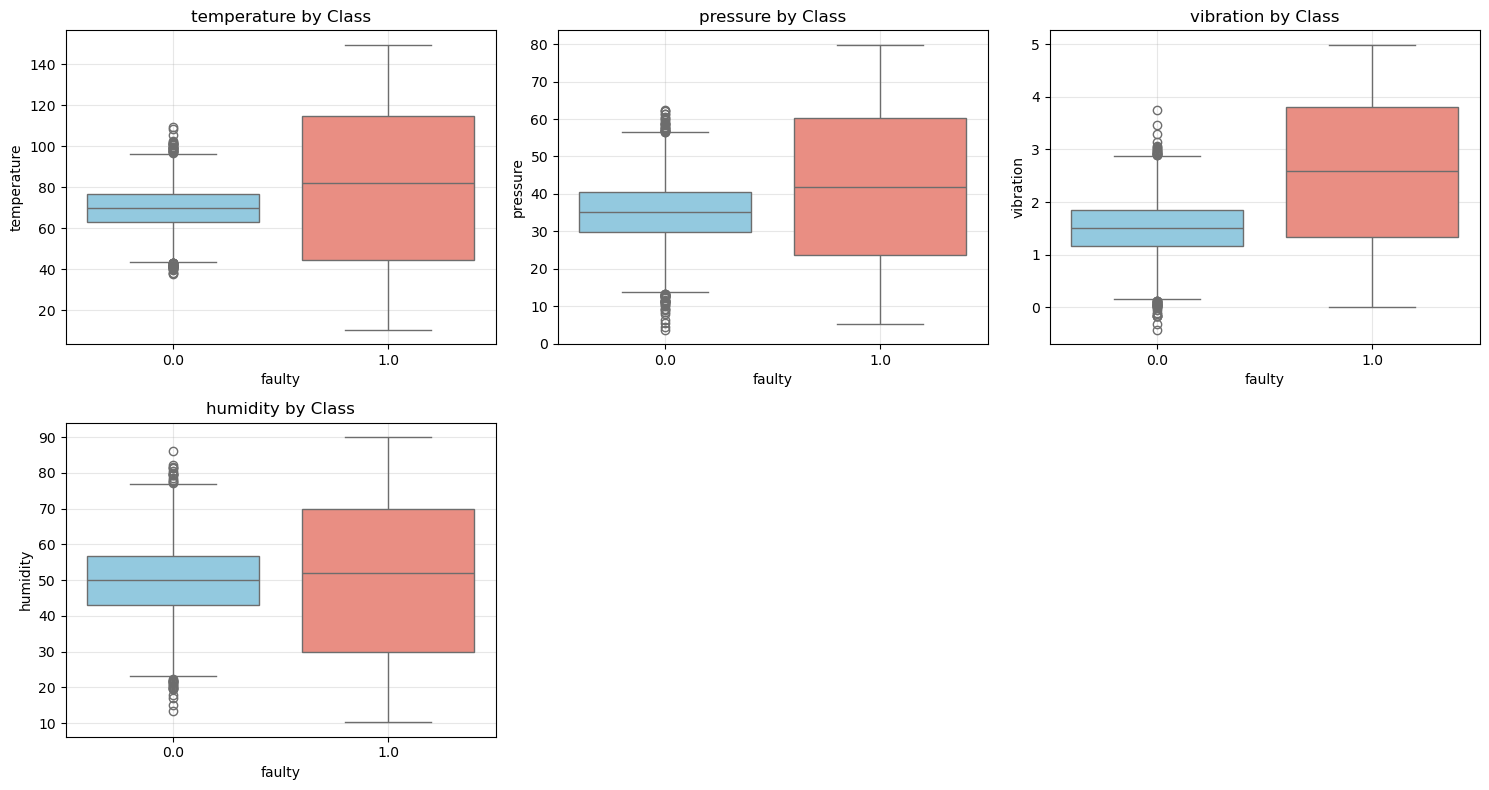

In [3]:

target_col = 'faulty'

num_cols = data_csv.select_dtypes(include='number').columns.drop(target_col)


n_cols = 3  
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.boxplot(
        x=target_col,
        y=col,
        data=data_csv,
        palette=['skyblue', 'salmon'],
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Class")
    axes[i].grid(alpha=0.3)


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Scatter plot temperature and pressure for Non faulty and faulty obserations

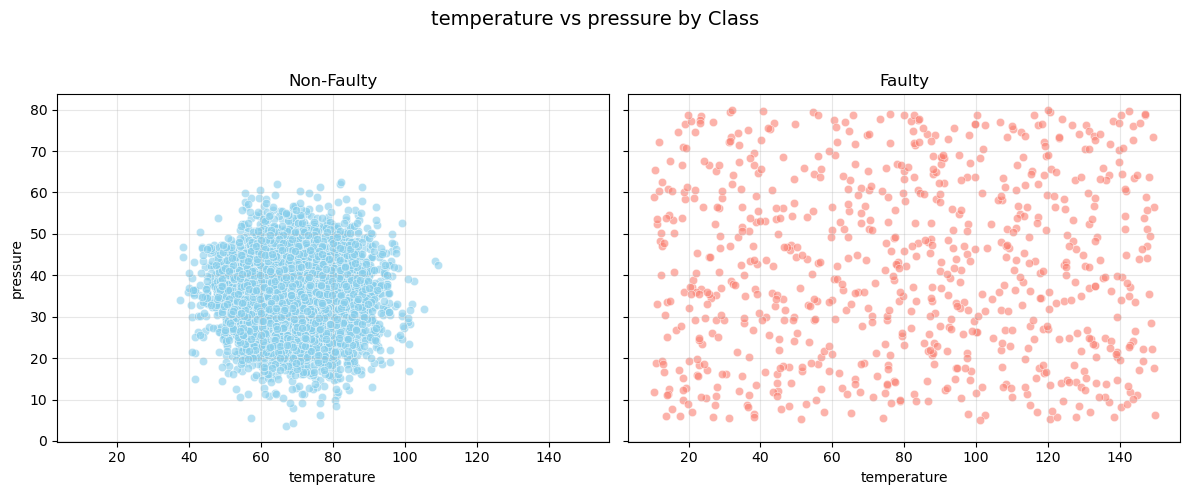

In [4]:
feature_x = 'temperature'
feature_y = 'pressure'
target_col = 'faulty'

df_non_faulty = data_csv[data_csv[target_col] == 0.0]
df_faulty     = data_csv[data_csv[target_col] == 1.0]


fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)


sns.scatterplot(
    x=feature_x,
    y=feature_y,
    data=df_non_faulty,
    color='skyblue',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Non-Faulty')
axes[0].set_xlabel(feature_x)
axes[0].set_ylabel(feature_y)
axes[0].grid(alpha=0.3)

# Faulty Class
sns.scatterplot(
    x=feature_x,
    y=feature_y,
    data=df_faulty,
    color='salmon',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Faulty')
axes[1].set_xlabel(feature_x)
axes[1].set_ylabel(feature_y)
axes[1].grid(alpha=0.3)

plt.suptitle(f"{feature_x} vs {feature_y} by Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Scatter plot vibration and pressure for Non faulty and faulty obserations

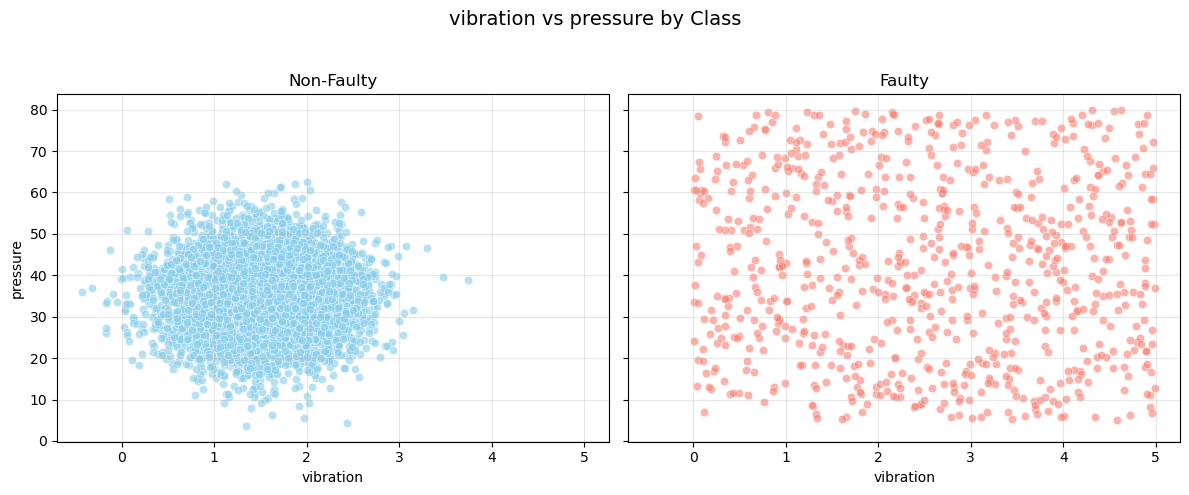

In [5]:


feature_x = 'vibration'
feature_y = 'pressure'
target_col = 'faulty'


df_non_faulty = data_csv[data_csv[target_col] == 0.0]
df_faulty     = data_csv[data_csv[target_col] == 1.0]

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

sns.scatterplot(
    x=feature_x,
    y=feature_y,
    data=df_non_faulty,
    color='skyblue',
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Non-Faulty')
axes[0].set_xlabel(feature_x)
axes[0].set_ylabel(feature_y)
axes[0].grid(alpha=0.3)


sns.scatterplot(
    x=feature_x,
    y=feature_y,
    data=df_faulty,
    color='salmon',
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Faulty')
axes[1].set_xlabel(feature_x)
axes[1].set_ylabel(feature_y)
axes[1].grid(alpha=0.3)

plt.suptitle(f"{feature_x} vs {feature_y} by Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Distribution plots of all sensors

# Creating training and testing sets for model implementation

In [6]:
data_csv[data_csv['faulty'] == 0.0]

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0
...,...,...,...,...,...,...,...
7665,62.179965,36.422638,1.565271,51.606218,Turbine,Atlanta,0.0
7666,69.587073,45.760937,1.269738,60.915675,Compressor,Houston,0.0
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0


In [7]:
#x_faulty,y_faulty = train_test_split(data_csv[data_csv['faulty'] == 1.0],test_size = 0.2,shuffle = True)

In [8]:
no_faulty_data = data_csv[data_csv['faulty'] == 0.0]

no_faulty_train, no_faulty_test = train_test_split(no_faulty_data, test_size=0.2, shuffle=True, random_state=42)

In [9]:
no_faulty_train = no_faulty_train.drop(['faulty','location','equipment'],axis = 1)

In [10]:
faulty_data = data_csv[data_csv['faulty'] == 1.0]
test = pd.concat([no_faulty_test, faulty_data], ignore_index=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)
X_test = test.drop(columns=['faulty']) 
y_test = test['faulty']               


In [11]:
X_test = X_test.drop(['location','equipment'],axis = 1)

Accuracy: 0.9798045602605863
F1 Score: 0.8912280701754386
Recall (faulty class): 0.8300653594771242

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1382
      Faulty       0.96      0.83      0.89       153

    accuracy                           0.98      1535
   macro avg       0.97      0.91      0.94      1535
weighted avg       0.98      0.98      0.98      1535

Confusion Matrix:
 [[1377    5]
 [  26  127]]


C:\Users\ismai\anaconda3\envs\project_clean\lib\site-packages\xgboost\training.py:199: UserWarning: [02:55:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


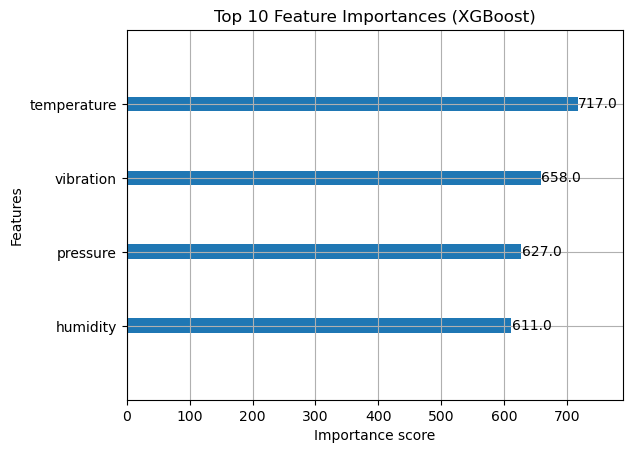

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Drop columns not useful for modeling
data = data_csv.drop(['location', 'equipment'], axis=1)

# Features and target
X = data.drop('faulty', axis=1)
y = data['faulty']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42, stratify=y
)
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Fit the model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred = xgb_model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Recall (faulty class):", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Normal','Faulty']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt

# Plot feature importance
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()


# Scaling and modelling the data

One class SVM

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(no_faulty_train)
X_test_scaled = scaler.transform(X_test)
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
ocsvm.fit(X_train_scaled)

OneClassSVM(gamma='auto', nu=0.05)

In [17]:
y_pred

[0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,


In [16]:
from sklearn.metrics import f1_score
y_pred = ocsvm.predict(X_test_scaled)
y_pred = [0 if i == 1 else 1 for i in y_pred]
f1_score(y_test, y_pred, average='weighted')


0.9425954056437538

Predicting for test set and heatmap of classification results

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95      1381
      Faulty       0.90      0.95      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1298   83]
 [  41  726]]


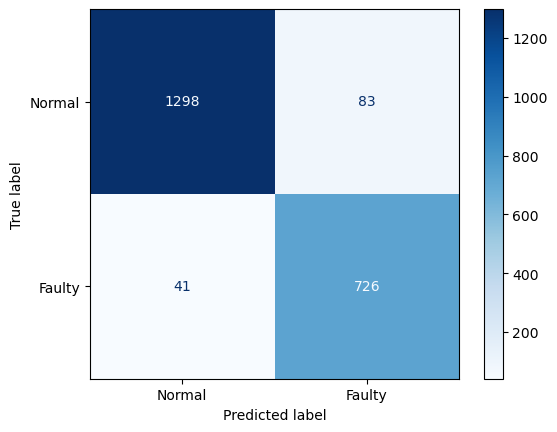

In [20]:
y_pred = ocsvm.predict(X_test_scaled)
y_pred = [0 if i == 1 else 1 for i in y_pred]

print(classification_report(y_test, y_pred, target_names=['Normal','Faulty']))

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Faulty'])
disp.plot(cmap=plt.cm.Blues)

plt.savefig("confusion_matrix_heatmap.png", dpi=300, bbox_inches='tight')  # <-- save here
plt.show()


Isolation forest modelling

In [21]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(no_faulty_train)
X_test_scaled = scaler.transform(X_test)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_train_scaled)


y_pred_train = iso_forest.predict(X_train_scaled)
y_pred_test = iso_forest.predict(X_test_scaled)


Prediction using the fitted isolation model

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95      1381
      Faulty       0.90      0.94      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1304   77]
 [  47  720]]


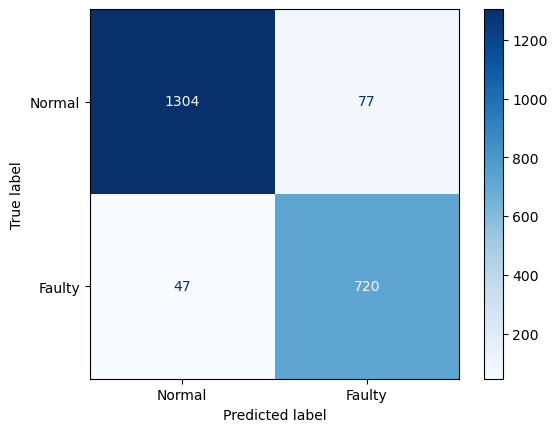

In [22]:
y_pred = iso_forest.predict(X_test_scaled)
y_pred = [0 if i == 1 else 1 for i in y_pred]

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred, target_names=['Normal', 'Faulty']))

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Faulty'])
disp.plot(cmap=plt.cm.Blues)

plt.savefig("isolation_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Separate normal and faulty
normal_data = data_csv[data_csv['faulty'] == 0.0]
faulty_data = data_csv[data_csv['faulty'] == 1.0]

# Train on normal only
normal_train, normal_test = train_test_split(
    normal_data,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Build test set (normal_test + all faulty)
test = pd.concat([normal_test, faulty_data], ignore_index=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Split X and y
X_train = normal_train.drop(['faulty','location','equipment'], axis=1)

X_test = test.drop(['faulty','location','equipment'], axis=1)
y_test = test['faulty']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

ocsvm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)

In [24]:
# Isolation Forest
iso.fit(X_train)
pred_if = iso.predict(X_test)
pred_if = (pred_if == -1).astype(int)  # map -1 to 1 (faulty)

# One-Class SVM
ocsvm_model.fit(X_train_scaled)
pred_oc = ocsvm_model.predict(X_test_scaled)
pred_oc = (pred_oc == -1).astype(int)


In [25]:
from sklearn.metrics import classification_report

print("Isolation Forest")
print(classification_report(y_test, pred_if))

print("One-Class SVM")
print(classification_report(y_test, pred_oc))


Isolation Forest
              precision    recall  f1-score   support

         0.0       0.97      0.94      0.95      1381
         1.0       0.90      0.94      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

One-Class SVM
              precision    recall  f1-score   support

         0.0       0.97      0.94      0.95      1381
         1.0       0.90      0.95      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148



In [ ]:
pip install statsmodels

In [26]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# Contingency table
both_correct = np.sum((pred_if == y_test) & (pred_oc == y_test))
if_correct = np.sum((pred_if == y_test) & (pred_oc != y_test))
oc_correct = np.sum((pred_if != y_test) & (pred_oc == y_test))
both_wrong = np.sum((pred_if != y_test) & (pred_oc != y_test))

table = [[both_correct, if_correct],
         [oc_correct, both_wrong]]

result = mcnemar(table, exact=True)
print("McNemar p-value:", result.pvalue)


McNemar p-value: 1.0


In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

n_runs = 10

rec_if = []
rec_oc = []

for i in range(n_runs):
    
    normal_train, normal_test = train_test_split(
        normal_data,
        test_size=0.2,
        shuffle=True,
        random_state=i
    )
    
    test = pd.concat([normal_test, faulty_data])
    test = test.sample(frac=1, random_state=i)
    
    X_train = normal_train.drop(['faulty','location','equipment'], axis=1)
    X_test = test.drop(['faulty','location','equipment'], axis=1)
    y_test = test['faulty']
    
    # Isolation Forest
    iso.fit(X_train)
    pred_if = (iso.predict(X_test) == -1).astype(int)
    rec_if.append(recall_score(y_test, pred_if, pos_label=1))
    
    # OC-SVM
    ocsvm.fit(X_train)
    pred_oc = (ocsvm.predict(X_test) == -1).astype(int)
    rec_oc.append(recall_score(y_test, pred_oc, pos_label=1))

print("Isolation Forest mean recall:", np.mean(rec_if))
print("Isolation Forest std:", np.std(rec_if))

print("OC-SVM mean recall:", np.mean(rec_oc))
print("OC-SVM std:", np.std(rec_oc))


Isolation Forest mean recall: 0.9305084745762713
Isolation Forest std: 0.0034519432320400875
OC-SVM mean recall: 0.9979139504563234
OC-SVM std: 0.0008648304538084793


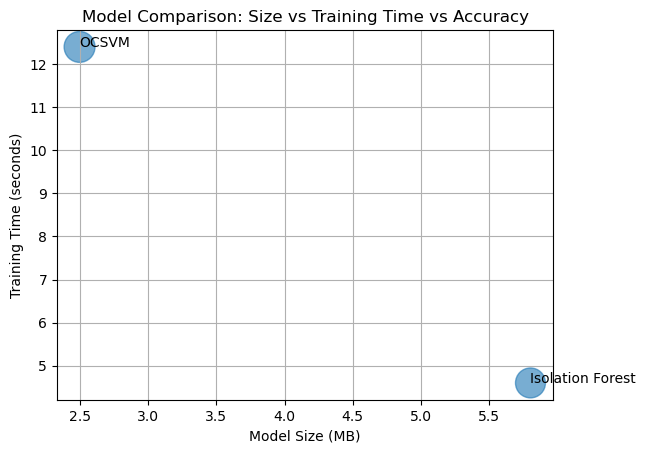

In [28]:
import matplotlib.pyplot as plt

models = ['OCSVM', 'Isolation Forest']
size = [2.5, 5.8]          # MB
time = [12.4, 4.6]         # seconds
accuracy = [0.99, 0.93]

plt.figure()
plt.scatter(size, time, s=[a*500 for a in accuracy], alpha=0.6)

for i, m in enumerate(models):
    plt.annotate(m, (size[i], time[i]))

plt.xlabel("Model Size (MB)")
plt.ylabel("Training Time (seconds)")
plt.title("Model Comparison: Size vs Training Time vs Accuracy")
plt.grid(True)

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [29]:
import time

start = time.time()
iso.predict(X_test)
print("Isolation Forest inference time:", time.time() - start)

start = time.time()
ocsvm.predict(X_test)
print("OC-SVM inference time:", time.time() - start)


Isolation Forest inference time: 0.010255098342895508
OC-SVM inference time: 0.35193753242492676


In [30]:
import pickle, os

pickle.dump(iso, open("iso.pkl","wb"))
pickle.dump(ocsvm, open("ocsvm.pkl","wb"))

print("IF size (KB):", os.path.getsize("iso.pkl")/1024)
print("OC-SVM size (KB):", os.path.getsize("ocsvm.pkl")/1024)


IF size (KB): 1089.0751953125
OC-SVM size (KB): 170.3076171875


In [31]:
from sklearn.metrics import recall_score
X_test_noisy = X_test + np.random.normal(0, 0.01, X_test.shape)

pred_if = (iso.predict(X_test_noisy) == -1).astype(int)
pred_oc = (ocsvm.predict(X_test_noisy) == -1).astype(int)

print("IF noisy recall:",
      recall_score(y_test, pred_if, pos_label=1))

print("OC noisy recall:",
      recall_score(y_test, pred_oc, pos_label=1))


IF noisy recall: 0.9269882659713168
OC noisy recall: 0.9973924380704041


In [32]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import recall_score

n_runs = 100  # more runs for better bootstrap estimate

rec_if = []
rec_oc = []

# Combine normal + faulty data for bootstrapping
full_data = pd.concat([normal_data, faulty_data])

for i in range(n_runs):
    # Bootstrap sample from full data
    boot_sample = resample(full_data, replace=True, n_samples=len(full_data), random_state=i)
    
    # Split into train/test
    X_train = boot_sample[boot_sample['faulty'] == 0].drop(['faulty','location','equipment'], axis=1)
    y_train = boot_sample[boot_sample['faulty'] == 0]['faulty']
    
    test = pd.concat([
        boot_sample[boot_sample['faulty'] == 1],  # all faulty in bootstrap
        boot_sample[boot_sample['faulty'] == 0].sample(frac=0.2, random_state=i)  # subset normal
    ])
    X_test = test.drop(['faulty','location','equipment'], axis=1)
    y_test = test['faulty']
    
    # Isolation Forest
    iso.fit(X_train)
    pred_if = (iso.predict(X_test) == -1).astype(int)
    rec_if.append(recall_score(y_test, pred_if, pos_label=1))
    
    # One-Class SVM
    ocsvm.fit(X_train)
    pred_oc = (ocsvm.predict(X_test) == -1).astype(int)
    rec_oc.append(recall_score(y_test, pred_oc, pos_label=1))

# Summary
print("Isolation Forest mean recall:", np.mean(rec_if), "±", np.std(rec_if))
print("OC-SVM mean recall:", np.mean(rec_oc), "±", np.std(rec_oc))


Isolation Forest mean recall: 0.9308225388722561 ± 0.01008598169554654
OC-SVM mean recall: 0.9986170163976013 ± 0.0018507188123636292


In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time

# ---- Metrics ----
if_recall_mean = np.mean(rec_if)
oc_recall_mean = np.mean(rec_oc)

if_size = os.path.getsize("iso.pkl") / 1024
oc_size = os.path.getsize("ocsvm.pkl") / 1024

start = time.time()
iso.predict(X_test)
if_time = time.time() - start

start = time.time()
ocsvm.predict(X_test)
oc_time = time.time() - start

# ---- DataFrame ----
comparison_df = pd.DataFrame({
    "Model": ["Isolation Forest", "One-Class SVM"],
    "Bootstrap Recall": [round(if_recall_mean, 3), round(oc_recall_mean, 3)],
    "Model Size(KB)": [round(if_size, 2), round(oc_size, 2)],
    "Training time(S)": [round(if_time, 6), round(oc_time, 6)]
})

# ---- Plot table ----
fig, ax = plt.subplots(figsize=(6, 1.5))  # smaller canvas
ax.axis('off')

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)

plt.savefig("model_comparison_table.png", dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.close()


In [34]:
import numpy as np

ci_low_if = np.percentile(rec_if, 2.5)
ci_high_if = np.percentile(rec_if, 97.5)

ci_low_oc = np.percentile(rec_oc, 2.5)
ci_high_oc = np.percentile(rec_oc, 97.5)

print(f"Isolation Forest 95% CI: [{ci_low_if:.3f}, {ci_high_if:.3f}]")
print(f"OC-SVM 95% CI: [{ci_low_oc:.3f}, {ci_high_oc:.3f}]")


Isolation Forest 95% CI: [0.909, 0.948]
OC-SVM 95% CI: [0.994, 1.000]


<Axes: xlabel='humidity', ylabel='Density'>

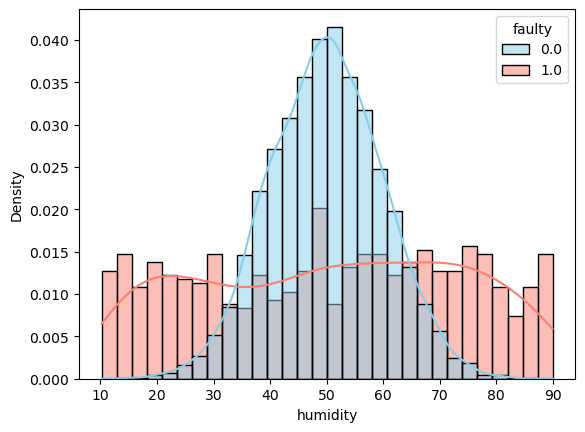

In [35]:
sns.histplot(
    data=data_csv,
    x=col,
    hue='faulty',
    kde=True,
    bins=30,
    stat='density',
    common_norm=False,  
    alpha=0.5,
    palette=['skyblue', 'salmon']
)


# Fitting an explainer module

In [13]:
subset = X_test_scaled[:1000]  
explainer = shap.KernelExplainer(lambda x: ocsvm.decision_function(x), X_train_scaled)
shap_values = explainer.shap_values(subset)

Using 5524 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [17:58<00:00,  1.08s/it]


In [12]:
import shap
shap.initjs()

In [17]:
import os
print(os.getcwd())

C:\Users\ismai\Downloads\fault detection project


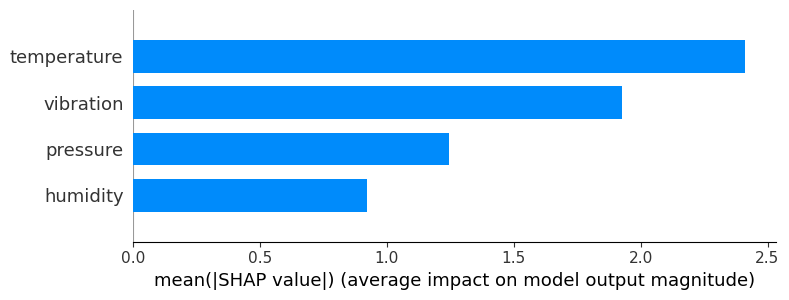

In [16]:
subset_df = pd.DataFrame(subset, columns=no_faulty_train.columns)

import matplotlib.pyplot as plt

shap.summary_plot(shap_values, subset_df, plot_type="bar")

plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.close()

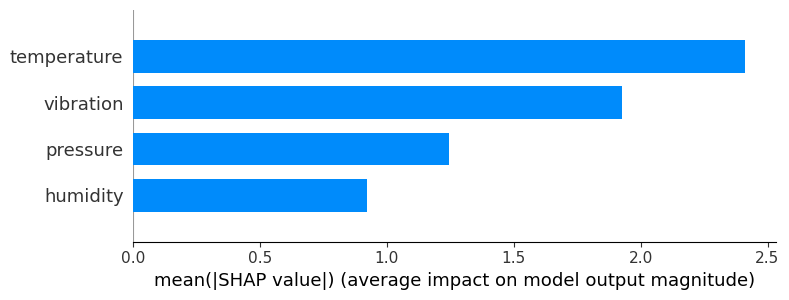

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    subset_df,
    plot_type="bar",
    show=False   # VERY IMPORTANT
)

plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
subset_df = pd.DataFrame(subset, columns=no_faulty_train.columns)
shap.summary_plot(shap_values, subset_df, plot_type="bar")

In [ ]:
subset_df = pd.DataFrame(subset, columns=no_faulty_train.columns)
shap.summary_plot(shap_values, subset_df, plot_type="bar")

In [ ]:
import pandas as pd
subset_df = pd.DataFrame(subset, columns=no_faulty_train.columns)
shap.summary_plot(shap_values, subset_df, plot_type="bar")

In [ ]:
import pandas as pd


subset_df = pd.DataFrame(subset, columns=no_faulty_train.columns)

shap.summary_plot(shap_values, subset_df, plot_type="bar")

# Sensitivity analysis of both models

In [36]:
nu_values = np.arange(0.01, 0.05, 0.001)
FP_list = []
FN_list = []

for nu in nu_values:
    ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=nu)
    ocsvm.fit(X_train_scaled)

    y_pred = ocsvm.predict(X_test_scaled)  
    y_pred_binary = np.where(y_pred == -1, 1, 0)  

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    
    FP_list.append(fp)
    FN_list.append(fn)


total_error = np.array(FP_list) + np.array(FN_list)
best_idx = np.argmin(total_error)
best_nu = nu_values[best_idx]
best_FP = FP_list[best_idx]
best_FN = FN_list[best_idx]

plt.figure(figsize=(10,6))
plt.plot(nu_values, FP_list, label='False Positives', marker='o')
plt.plot(nu_values, FN_list, label='False Negatives', marker='x')
plt.axvline(best_nu, color='r', linestyle='--', label=f'Optimal nu={best_nu:.3f}')
plt.scatter(best_nu, best_FP, color='blue')  
plt.scatter(best_nu, best_FN, color='orange')
plt.xlabel('nu value')
plt.ylabel('Count')
plt.title('OC-SVM: False Positives & False Negatives vs nu')
plt.legend()
plt.grid(True)
plt.show()
print(f"Optimal nu: {best_nu:.3f}")
print(f"FP at optimal nu: {best_FP}, FN at optimal nu: {best_FN}")
print(f"Total misclassifications: {best_FP + best_FN}")

ValueError: Found input variables with inconsistent numbers of samples: [2161, 2148]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# ---- Range of nu values ----
nu_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []
balanced_acc_list = []

for nu in nu_values:
    
    # Train only on NORMAL data
    ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=nu)
    ocsvm.fit(X_train_scaled)

    # Predict
    y_pred = ocsvm.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)  # anomaly=1, normal=0

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    
    FP_list.append(fp)
    FN_list.append(fn)
    
    # Balanced accuracy (better for imbalanced data)
    bal_acc = balanced_accuracy_score(y_test, y_pred_binary)
    balanced_acc_list.append(bal_acc)

# ---- Select best nu (maximize balanced accuracy) ----
best_idx = np.argmax(balanced_acc_list)
best_nu = nu_values[best_idx]
best_FP = FP_list[best_idx]
best_FN = FN_list[best_idx]
best_bal_acc = balanced_acc_list[best_idx]

# ---- Plot ----
plt.figure(figsize=(8,5))

plt.plot(nu_values, FP_list, label='False Positives', marker='o')
plt.plot(nu_values, FN_list, label='False Negatives', marker='x')
plt.axvline(best_nu, linestyle='--', label=f'Optimal nu = {best_nu:.3f}')

plt.xlabel('nu value')
plt.ylabel('Count')
plt.title('OC-SVM: FP & FN vs nu')
plt.legend()
plt.grid(True)

plt.savefig("ocsvm_nu_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Results ----
print(f"Optimal nu: {best_nu:.3f}")
print(f"Balanced Accuracy at optimal nu: {best_bal_acc:.4f}")
print(f"FP at optimal nu: {best_FP}")
print(f"FN at optimal nu: {best_FN}")
print(f"Total Misclassifications: {best_FP + best_FN}")


In [ ]:
import numpy as np

# OCSVM
print("OCSVM balanced accuracy mean:", np.mean(balanced_acc_list))
print("OCSVM balanced accuracy std:", np.std(balanced_acc_list))

# Isolation Forest
print("IF balanced accuracy mean:", np.mean(balanced_acc_list_isolation))
print("IF balanced accuracy std:", np.std(balanced_acc_list_isolation))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['OCSVM', 'Isolation Forest']

# Mean and std (from your calculation)
mean_acc = [np.mean(balanced_acc_list), np.mean(balanced_acc_list_isolation)]
std_acc = [np.std(balanced_acc_list), np.std(balanced_acc_list_isolation)]

# Plot
plt.figure(figsize=(6,5))
plt.bar(models, mean_acc, yerr=std_acc, capsize=8, color=['skyblue','lightgreen'])
plt.ylabel('Balanced Accuracy')
plt.ylim(0, 1)
plt.title('Model Performance: Mean ± Std Across Hyperparameter Sweep')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate mean values
for i, v in enumerate(mean_acc):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("model_accuracy_comparison1.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# ---- Range of contamination values ----
contamination_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []
balanced_acc_list_isolation = []

for c in contamination_values:
    # Train only on normal data
    iso = IsolationForest(contamination=c, random_state=42)
    iso.fit(X_train_scaled)

    # Predict
    y_pred = iso.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)  # anomaly=1, normal=0

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    
    FP_list.append(fp)
    FN_list.append(fn)
    
    # Balanced accuracy
    bal_acc = balanced_accuracy_score(y_test, y_pred_binary)
    balanced_acc_list_isolation.append(bal_acc)

# ---- Select best contamination ----
best_idx = np.argmax(balanced_acc_list_isolation)
best_c = contamination_values[best_idx]
best_FP = FP_list[best_idx]
best_FN = FN_list[best_idx]
best_bal_acc = balanced_acc_list_isolation[best_idx]

# ---- Plot ----
plt.figure(figsize=(8,5))

plt.plot(contamination_values, FP_list, label='False Positives', marker='o')
plt.plot(contamination_values, FN_list, label='False Negatives', marker='x')
plt.axvline(best_c, linestyle='--', color='r', label=f'Optimal contamination = {best_c:.3f}')

plt.xlabel('contamination')
plt.ylabel('Count')
plt.title('Isolation Forest: FP & FN vs contamination')
plt.legend()
plt.grid(True)

plt.savefig("if_contamination_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Results ----
print(f"Optimal contamination: {best_c:.3f}")
print(f"Balanced Accuracy at optimal contamination: {best_bal_acc:.4f}")
print(f"FP at optimal contamination: {best_FP}")
print(f"FN at optimal contamination: {best_FN}")
print(f"Total Misclassifications: {best_FP + best_FN}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ['OCSVM', 'Isolation Forest']
x = np.arange(len(models))

# Mean and std
mean_acc = [np.mean(balanced_acc_list), np.mean(balanced_acc_list_isolation)]
std_acc = [np.std(balanced_acc_list), np.std(balanced_acc_list_isolation)]

# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(x, mean_acc, s=100, color=['blue','green'], label='Mean Balanced Accuracy')

# Add error bars
plt.errorbar(x, mean_acc, yerr=std_acc, fmt='o', color='black', capsize=5)

plt.xticks(x, models)
plt.ylabel('Balanced Accuracy')
plt.ylim(0, 1)
plt.title('Balanced Accuracy of Models Across Hyperparameter Sweep')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("model_accuracy_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
/

In [ ]:
plt.figure(figsize=(6,5))
plt.bar(models, mean_acc, yerr=std_acc, capsize=8, color=['blue','green'])
plt.ylabel('Balanced Accuracy')
plt.ylim(0, 1)
plt.title('Balanced Accuracy of Models Across Hyperparameter Sweep')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("model_accuracy_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models and metrics
models = ['OCSVM', 'Isolation Forest']
mean_acc = [np.mean(balanced_acc_list), np.mean(balanced_acc_list_isolation)]
std_acc = [np.std(balanced_acc_list), np.std(balanced_acc_list_isolation)]
colors = ['blue', 'green']

# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(mean_acc, std_acc, s=200, c=colors)

# Annotate model names
for i, model in enumerate(models):
    plt.text(mean_acc[i]+0.0005, std_acc[i]+0.0005, model, fontsize=12, fontweight='bold')

plt.xlabel('Mean Balanced Accuracy')
plt.ylabel('Standard Deviation (Consistency)')
plt.title('Model Performance vs Robustness')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0.92, 1.0)
plt.ylim(0, max(std_acc)*1.5)

plt.savefig("model_accuracy_vs_std.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models and metrics
models = ['OCSVM', 'Isolation Forest']
mean_acc = [np.mean(balanced_acc_list), np.mean(balanced_acc_list_isolation)]
std_acc = [np.std(balanced_acc_list), np.std(balanced_acc_list_isolation)]
colors = ['blue', 'green']

# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(std_acc, mean_acc, s=200, c=colors)

# Annotate model names
for i, model in enumerate(models):
    plt.text(std_acc[i]+0.0002, mean_acc[i]-0.0005, model, fontsize=12, fontweight='bold')

plt.xlabel('Standard Deviation (Consistency)')
plt.ylabel('Mean Balanced Accuracy')
plt.title('Model Accuracy vs Consistency')
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: adjust limits to make visualization clear
plt.xlim(0, max(std_acc)*1.5)
plt.ylim(min(mean_acc)-0.1, 1.0)

plt.savefig("model_accuracy_vs_std_flipped.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
print(X_test_scaled.shape, y_test.shape)


Evaluating the decision boundary of the One svm using the anamoly score of the one SVM model

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(no_faulty_train)
X_test_scaled = scaler.transform(X_test)

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm.fit(X_train_scaled)


y_pred = ocsvm.predict(X_test_scaled)

y_pred_binary = np.array([0 if i == 1 else 1 for i in y_pred])

print(classification_report(y_test, y_pred_binary, target_names=['Normal','Faulty']))
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Faulty'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ----------------------------
# Compute anomaly scores
# ----------------------------
scores = ocsvm.decision_function(X_test_scaled)
anomaly_scores = -scores  
sample_idx = np.arange(len(y_test))

# True positives: predicted faulty AND actually faulty
tp_idx = np.where((y_pred_binary == 1) & (y_test == 1))[0]
# False positives: predicted faulty BUT actually normal
fp_idx = np.where((y_pred_binary == 1) & (y_test == 0))[0]
# False negatives: predicted normal BUT actually faulty
fn_idx = np.where((y_pred_binary == 0) & (y_test == 1))[0]

plt.figure(figsize=(12,6))
plt.scatter(tp_idx, anomaly_scores[tp_idx], color='green', label='True Positive', alpha=0.7)
plt.scatter(fp_idx, anomaly_scores[fp_idx], color='red', label='False Positive', alpha=0.7)
plt.scatter(fn_idx, anomaly_scores[fn_idx], color='orange', label='False Negative', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.title('OC-SVM: Anomaly Scores with TP / FP / FN Highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(no_faulty_train) 
X_test_scaled = scaler.transform(X_test)

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm.fit(X_train_scaled)

y_pred = ocsvm.predict(X_test_scaled)

y_pred_binary = np.array([0 if i == 1 else 1 for i in y_pred])

print(classification_report(y_test, y_pred_binary, target_names=['Normal','Faulty']))
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Faulty'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


scores = ocsvm.decision_function(X_test_scaled)
anomaly_scores = -scores  


pred_faulty_idx = np.where(y_pred_binary == 1)[0]


tp_idx = [i for i in pred_faulty_idx if y_test[i] == 1]  
fp_idx = [i for i in pred_faulty_idx if y_test[i] == 0] 

# Scatter plot
plt.figure(figsize=(12,6))
plt.scatter(tp_idx, anomaly_scores[tp_idx], color='green', label='True Positive', alpha=0.7)
plt.scatter(fp_idx, anomaly_scores[fp_idx], color='red', label='False Positive', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.title('OC-SVM: Predicted Faulty Samples (TP / FP Highlighted)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_anomaly_scores(model, X_test_scaled, y_test, model_name, filename):
    # Compute anomaly scores
    if model_name == "OCSVM":
        scores = model.decision_function(X_test_scaled)
    elif model_name == "Isolation Forest":
        scores = model.decision_function(X_test_scaled)
    else:
        raise ValueError("Unknown model")

    anomaly_scores = -scores  # higher = more anomalous

    # Predicted labels
    y_pred_binary = np.where(model.predict(X_test_scaled) == -1, 1, 0)

    # Indices
    pred_faulty_idx = np.where(y_pred_binary == 1)[0]
    tp_idx = [i for i in pred_faulty_idx if y_test[i] == 1]
    fp_idx = [i for i in pred_faulty_idx if y_test[i] == 0]
    fn_idx = [i for i, i_test in enumerate(y_test) if i_test == 1 and y_pred_binary[i] == 0]

    # Scatter plot
    plt.figure(figsize=(12,6))
    
    # TP
    plt.scatter(tp_idx, anomaly_scores[tp_idx], color='green', label='True Positive', alpha=0.7)
    # FP
    plt.scatter(fp_idx, anomaly_scores[fp_idx], color='red', label='False Positive', alpha=0.7)
    # FN
    plt.scatter(fn_idx, anomaly_scores[fn_idx], color='orange', label='False Negative', alpha=0.7)

    # Decision boundary line
    plt.axhline(y=0, color='black', linestyle='--', label='Decision Boundary')

    plt.xlabel('Sample Index')
    plt.ylabel('Anomaly Score')
    plt.title(f'{model_name}: Predicted Faulty Samples (TP / FP / FN Highlighted)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save plot
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


# --- Example usage ---

# OCSVM
plot_anomaly_scores(ocsvm, X_test_scaled, y_test.values, "OCSVM", "ocsvm_anomaly_scores.png")

# Isolation Forest
plot_anomaly_scores(iso, X_test_scaled, y_test.values, "Isolation Forest", "if_anomaly_scores.png")


In [ ]:


temperature = X_test['temperature'].values  

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(no_faulty_train) 
X_test_scaled = scaler.transform(X_test)


ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm.fit(X_train_scaled)

y_pred = ocsvm.predict(X_test_scaled)

y_pred_binary = np.array([0 if i == 1 else 1 for i in y_pred])


print(classification_report(y_test, y_pred_binary, target_names=['Normal','Faulty']))
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Faulty'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ----------------------------
# Compute anomaly scores
# ----------------------------
scores = ocsvm.decision_function(X_test_scaled)
anomaly_scores = -scores  # higher = more anomalous

# ----------------------------
# Only predicted faulty samples
# ----------------------------
pred_faulty_idx = np.where(y_pred_binary == 1)[0]


tp_idx = [i for i in pred_faulty_idx if y_test[i] == 1] 
fp_idx = [i for i in pred_faulty_idx if y_test[i] == 0] 

# Scatter plot: anomaly score vs temperature
plt.figure(figsize=(10,8))
plt.scatter(temperature[tp_idx],anomaly_scores[tp_idx] , color='green', label='True Positive', alpha=0.7)
plt.scatter(temperature[fp_idx], anomaly_scores[fp_idx], color='red', label='False Positive', alpha=0.7)

plt.xlabel('Anomaly Score')
plt.ylabel('Temperature')
plt.title('OC-SVM: Predicted Faulty Samples (TP / FP) vs Temperature')
plt.legend()
plt.grid(True)
plt.show()
